##### Cellule 1 : Imports & chargement du DataFrame feature-engineered

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Charger le DataFrame propre depuis le notebook 02
# (relancer les cellules 1 et 2 du notebook 02 pour recréer d_clean)
exec(open('../notebooks/02_feature_engineering.ipynb').read()) \
    if False else None

# Recharger proprement
train    = pd.read_csv('../data/train.csv',           parse_dates=['date'])
stores   = pd.read_csv('../data/stores.csv')
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
oil      = pd.read_csv('../data/oil.csv',             parse_dates=['date'])
transac  = pd.read_csv('../data/transactions.csv',    parse_dates=['date'])

df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(transac,   on=['date','store_nbr'], how='left')
df = df.merge(oil,       on='date', how='left')
hol = holidays[holidays['transferred']==False][['date','type','locale']]
hol = hol.rename(columns={'type':'holiday_type','locale':'holiday_locale'})
df  = df.merge(hol, on='date', how='left')
df['is_holiday']    = df['holiday_type'].notna().astype('int8')
df['has_promotion'] = (df['onpromotion'] > 0).astype(int)
df['dcoilwtico']    = df['dcoilwtico'].ffill().bfill()
df['transactions']  = df['transactions'].fillna(0).astype('int32')

# Isolation + features
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import build_features
d_clean = build_features(df, store_nbr=1, family='GROCERY I')

FEAT_COLS = [c for c in d_clean.columns if c != 'sales']
print(f"Prêt : {len(d_clean)} lignes · {len(FEAT_COLS)} features")

[build_features] 1 · GROCERY I
  Lignes avant dropna : 1714
  Lignes après dropna : 1686
  Features construites : 37
Prêt : 1686 lignes · 37 features


##### Cellule 2 : Validation croisée temporelle (TimeSeriesSplit)

In [3]:

# On utilise TimeSeriesSplit pour une évaluation plus robuste
tscv = TimeSeriesSplit(n_splits=5)
X = d_clean[FEAT_COLS]
y = d_clean['sales']

BASIC_FEATS = ['day_of_week','day_of_month','month','is_weekend',
               'is_holiday','has_promotion','quarter']

cv_base, cv_full = [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    m_b = XGBRegressor(n_estimators=300, learning_rate=0.05,
                       max_depth=4, random_state=42)
    m_b.fit(X_tr[BASIC_FEATS], y_tr)
    cv_base.append(mean_absolute_error(y_te, m_b.predict(X_te[BASIC_FEATS])))

    m_f = XGBRegressor(n_estimators=500, learning_rate=0.05,
                       max_depth=6, random_state=42)
    m_f.fit(X_tr, y_tr)
    cv_full.append(mean_absolute_error(y_te, m_f.predict(X_te)))

    print(f"Fold {fold+1} — Baseline: {cv_base[-1]:.1f} · Complet: {cv_full[-1]:.1f}")

print(f"\nMoyenne CV — Baseline : {np.mean(cv_base):.1f} ± {np.std(cv_base):.1f}")
print(f"Moyenne CV — Complet  : {np.mean(cv_full):.1f} ± {np.std(cv_full):.1f}")
print(f"Réduction moyenne     : −{(1 - np.mean(cv_full)/np.mean(cv_base))*100:.1f}%")

Fold 1 — Baseline: 323.0 · Complet: 248.6
Fold 2 — Baseline: 279.7 · Complet: 228.5
Fold 3 — Baseline: 291.6 · Complet: 236.8
Fold 4 — Baseline: 424.3 · Complet: 294.6
Fold 5 — Baseline: 460.0 · Complet: 325.8

Moyenne CV — Baseline : 355.7 ± 72.9
Moyenne CV — Complet  : 266.9 ± 37.3
Réduction moyenne     : −25.0%


##### Cellule 3 : Entraînement final + courbes d'apprentissage

Meilleure itération   : 112
MAE  final            : 274.02
RMSE final            : 416.62
MAE / moyenne ventes  : 10.4% (erreur relative)


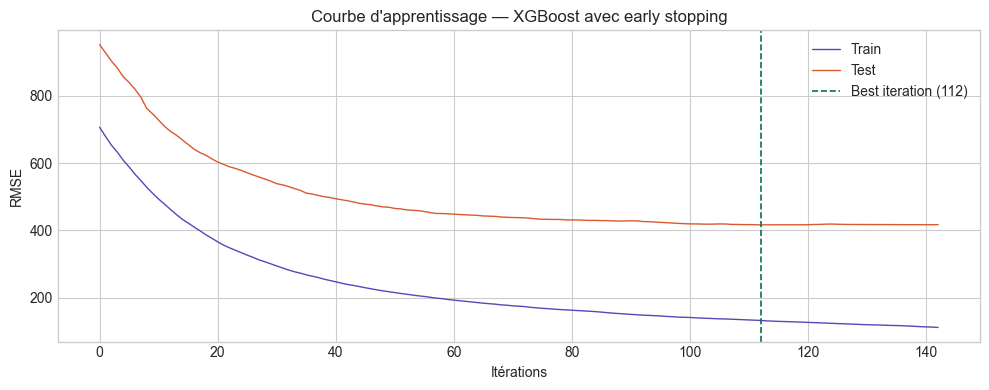

In [4]:

split = int(len(d_clean) * 0.8)
X_train = d_clean[FEAT_COLS].iloc[:split]
X_test  = d_clean[FEAT_COLS].iloc[split:]
y_train = d_clean['sales'].iloc[:split]
y_test  = d_clean['sales'].iloc[split:]

# Entraînement avec early stopping
m_final = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    early_stopping_rounds=30, random_state=42
)
m_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

pred_final = m_final.predict(X_test)
mae_final  = mean_absolute_error(y_test, pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, pred_final))

print(f"Meilleure itération   : {m_final.best_iteration}")
print(f"MAE  final            : {mae_final:.2f}")
print(f"RMSE final            : {rmse_final:.2f}")
print(f"MAE / moyenne ventes  : {mae_final / y_test.mean() * 100:.1f}% (erreur relative)")

# Courbes d'apprentissage
results = m_final.evals_result()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(results['validation_0']['rmse'], label='Train', color='#534AB7', linewidth=1)
ax.plot(results['validation_1']['rmse'], label='Test',  color='#D85A30', linewidth=1)
ax.axvline(m_final.best_iteration, color='#0F6E56', linestyle='--',
           linewidth=1.2, label=f'Best iteration ({m_final.best_iteration})')
ax.set_title('Courbe d\'apprentissage — XGBoost avec early stopping', fontsize=12)
ax.set_xlabel('Itérations')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig('../resultats_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 4 : Prédictions vs Réel + résidus

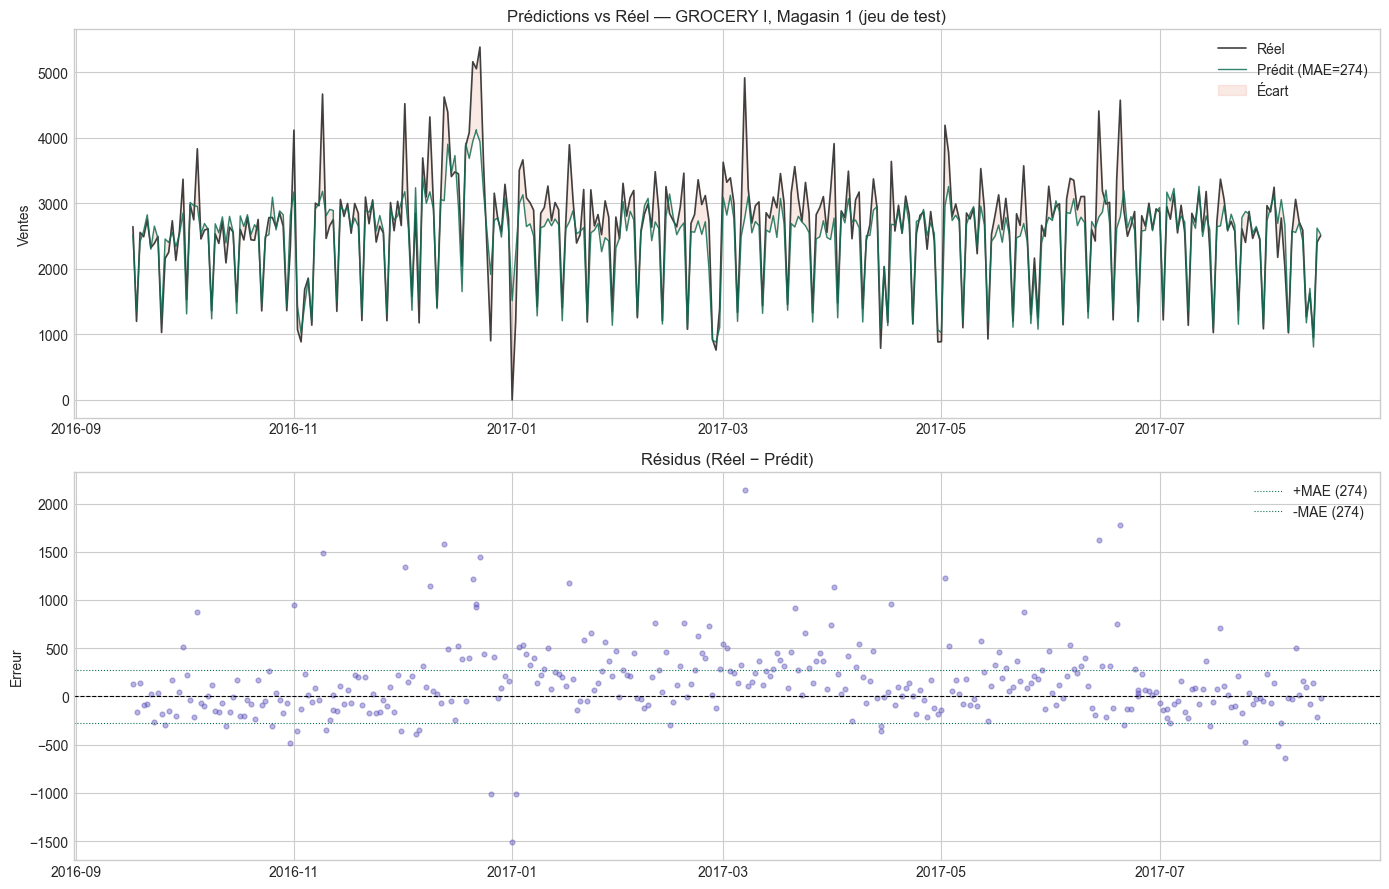

Modèle sauvegardé → models/xgboost_grocery1_store1.pkl


In [5]:


fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Prédictions vs Réel
axes[0].plot(y_test.index, y_test.values,
             label='Réel', color='#2d2d2d', linewidth=1.2, alpha=0.9)
axes[0].plot(y_test.index, pred_final,
             label=f'Prédit (MAE={mae_final:.0f})',
             color='#0F6E56', linewidth=1, alpha=0.85)
axes[0].fill_between(y_test.index, y_test.values, pred_final,
                     alpha=0.12, color='#D85A30', label='Écart')
axes[0].set_title('Prédictions vs Réel — GROCERY I, Magasin 1 (jeu de test)', fontsize=12)
axes[0].set_ylabel('Ventes')
axes[0].legend(fontsize=10)

# Résidus
residus = y_test.values - pred_final
axes[1].scatter(y_test.index, residus, alpha=0.4, s=12, color='#534AB7')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(mae_final,  color='#0F6E56', linewidth=0.8,
                linestyle=':', label=f'+MAE ({mae_final:.0f})')
axes[1].axhline(-mae_final, color='#0F6E56', linewidth=0.8,
                linestyle=':', label=f'-MAE ({mae_final:.0f})')
axes[1].set_title('Résidus (Réel − Prédit)', fontsize=12)
axes[1].set_ylabel('Erreur')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../resultats_predictions_residus.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder le modèle
import joblib, os
os.makedirs('../models', exist_ok=True)
joblib.dump(m_final, '../models/xgboost_grocery1_store1.pkl')
print("Modèle sauvegardé → models/xgboost_grocery1_store1.pkl")